In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np

In [15]:
# =============================================================================
# Configuration
# =============================================================================

sns.set_theme(style="whitegrid")

FILE_PATHS = [
    "COFCO Tunhe Sugar Stock Price History.csv",
    "USD_CNY Historical Data.csv",
    "Davis Commodities Stock Price History.csv",
    "S&P 500 Historical Data.csv",
    "Shanghai Composite Historical Data.csv",
    "CBOE Volatility Index Historical Data.csv",
    "3037 ETF Stock Price History.csv",
]

LABELS = [
    "COFCO Tunhe",
    "USD/CNY",
    "Davis Commodities",
    "S&P 500",
    "Shanghai Composite",
    "CBOE Volatility Index",
    "HK Index",
]

marker_dates = pd.to_datetime([
    "2025-01-20", "2025-01-26",
    "2025-02-01", "2025-02-03", "2025-02-04",
    "2025-02-10", "2025-02-13", "2025-02-25",
    "2025-03-01", "2025-03-04", "2025-03-05",
    "2025-03-06", "2025-03-10", "2025-03-12",
    "2025-03-13", "2025-03-24", "2025-03-26",
    "2025-04-02", "2025-04-03", "2025-04-04",
    "2025-04-05", "2025-04-09", "2025-04-10",
])

# =============================================================================
# Data Loading
# =============================================================================

def load_price_series(file_path: str) -> pd.DataFrame:
    """
    Load and preprocess a single financial time series.

    Parameters
    ----------
    file_path : str
        Path to the CSV file.

    Returns
    -------
    pd.DataFrame
        Preprocessed dataframe indexed by date.
    """

    df = pd.read_csv(
        file_path,
        thousands=",",
        quotechar='"',
    )

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
    )

    required_columns = {"date", "price"}
    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"{file_path} is missing required columns: {missing}"
        )

    df["date"] = pd.to_datetime(df["date"])
    df = (
        df.sort_values("date")
          .set_index("date")
    )

    df["normalized"] = (
        100 * df["price"] / df["price"].iloc[0]
    )

    return df


def load_all_series(file_paths, labels):
    """
    Load all datasets.

    Returns
    -------
    list[tuple[pd.DataFrame, str]]
    """

    if len(file_paths) != len(labels):
        raise ValueError(
            "file_paths and labels must have the same length."
        )

    return [
        (load_price_series(path), label)
        for path, label in zip(file_paths, labels)
    ]


# =============================================================================
# Main
# =============================================================================

series_list = load_all_series(FILE_PATHS, LABELS)

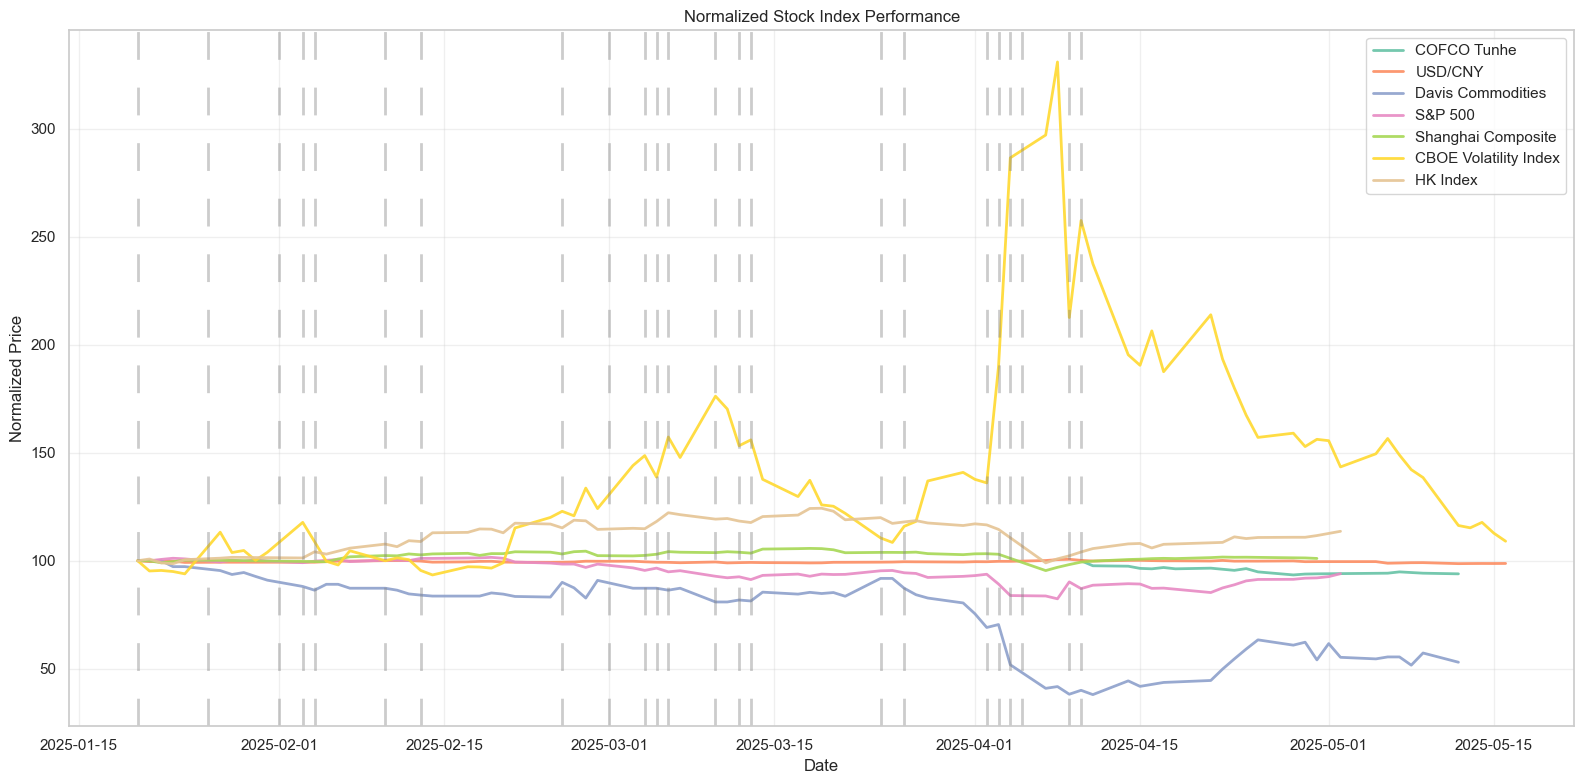


Correlation Matrix of Log Returns

                       COFCO Tunhe  USD/CNY  Davis Commodities  S&P 500  \
COFCO Tunhe                  1.000    0.055              0.224   -0.088   
USD/CNY                      0.055    1.000              0.245    0.084   
Davis Commodities            0.224    0.245              1.000    0.373   
S&P 500                     -0.088    0.084              0.373    1.000   
Shanghai Composite          -0.117    0.279              0.442    0.076   
CBOE Volatility Index       -0.047   -0.285             -0.651   -0.665   
HK Index                    -0.179   -0.017              0.204    0.546   

                       Shanghai Composite  CBOE Volatility Index  HK Index  
COFCO Tunhe                        -0.117                 -0.047    -0.179  
USD/CNY                             0.279                 -0.285    -0.017  
Davis Commodities                   0.442                 -0.651     0.204  
S&P 500                             0.076              

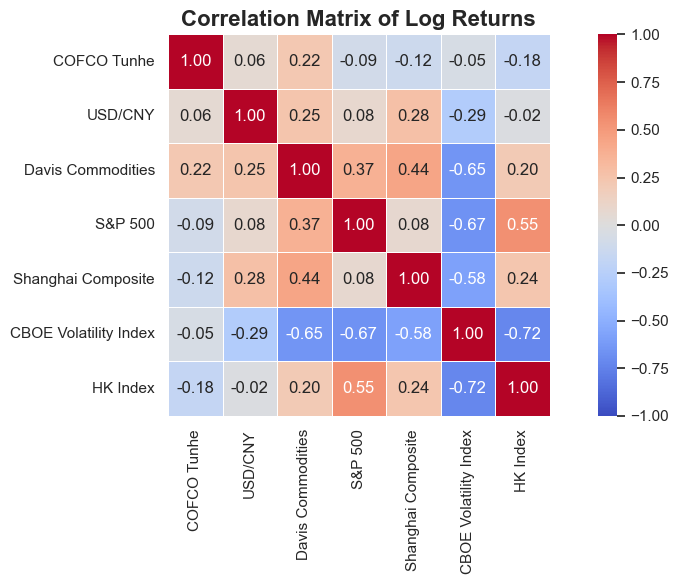

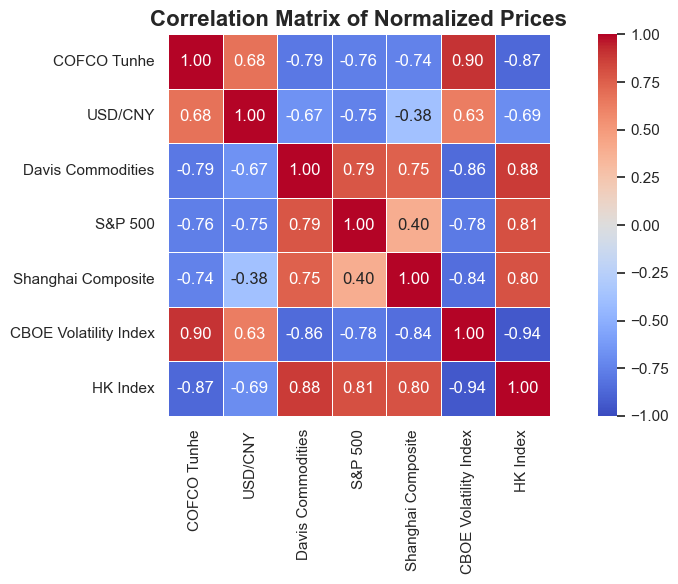

In [18]:



def plot_normalized_series(
    series_list,
    marker_dates=None,
    figsize=(16, 8),
):
    """
    Plot normalized price series.

    Parameters
    ----------
    series_list : list[tuple[pd.DataFrame, str]]
        List containing (DataFrame, label) tuples.
        Each DataFrame must contain a 'normalized' column.
    marker_dates : iterable, optional
        Dates at which vertical markers should be drawn.
    figsize : tuple
        Figure size.
    """

    marker_dates = [] if marker_dates is None else marker_dates

    plt.figure(figsize=figsize)

    colors = sns.color_palette("Set2", len(series_list))

    for color, (df, label) in zip(colors, series_list):
        plt.plot(
            df.index,
            df["normalized"],
            label=label,
            color=color,
            linewidth=2,
            alpha=0.9,
        )

    for date in marker_dates:
        plt.axvline(
            x=date,
            color="gray",
            linestyle="--",
            linewidth=2,
            alpha=0.4,
            dashes=(10, 10),
        )

    plt.title("Normalized Stock Index Performance")
    plt.xlabel("Date")
    plt.ylabel("Normalized Price")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def calculate_correlation_matrices(series_list):
    """
    Calculate correlation matrices for
    log returns and normalized prices.

    Returns
    -------
    tuple[pd.DataFrame, pd.DataFrame]
        (log_return_correlation, normalized_price_correlation)
    """

    log_returns = {}
    normalized_prices = {}

    for df, label in series_list:

        required_columns = {"price", "normalized"}
        missing = required_columns - set(df.columns)

        if missing:
            raise ValueError(
                f"'{label}' is missing required columns: {missing}"
            )

        log_returns[label] = np.log(df["price"]).diff()
        normalized_prices[label] = df["normalized"]

    log_df = pd.DataFrame(log_returns).dropna(how="any")
    normalized_df = pd.DataFrame(normalized_prices).dropna(how="any")

    return log_df.corr(), normalized_df.corr()


def plot_correlation_heatmap(
    correlation_matrix,
    title,
    figsize=(10, 6),
):
    """
    Plot a correlation matrix heatmap.
    """

    plt.figure(figsize=figsize)

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        square=True,
        vmin=-1,
        vmax=1,
    )

    plt.title(title, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


# =============================================================================
# Main
# =============================================================================

plot_normalized_series(series_list, marker_dates)

corr_log, corr_normalized = calculate_correlation_matrices(series_list)

print("\nCorrelation Matrix of Log Returns\n")
print(corr_log.round(3))

print("\nCorrelation Matrix of Normalized Prices\n")
print(corr_normalized.round(3))

plot_correlation_heatmap(
    corr_log,
    "Correlation Matrix of Log Returns",
)

plot_correlation_heatmap(
    corr_normalized,
    "Correlation Matrix of Normalized Prices",
)

# Analysis of US-China Stock Indexes During Trade Tensions

## Index Selection Rationale
The analysis incorporates key indexes from both the US and China to assess the impact of trade tensions:
- **COFCO Tunhe Sugar Co Ltd**: A Chinese sugar-producing company used as a proxy for broader Chinese commodity sector performance, due to the lack of a publicly available Chinese commodities index.
- **USD/CNY**: Tracks currency dynamics amid tariff announcements.
- **S&P 500 & Shanghai Composite**: Represent US and Chinese equity markets, respectively.
- **CBOE Volatility Index (VIX)**: Measures market uncertainty.
- **Davis Commodities**: Based in Singapore but listed on the NASDAQ exchange, giving it high sensitivity to U.S. market sentiment, inflation expectations, and trade policy.

---

## Graph Observations

### 1. Commodity Index (Davis Commodities)
- **Sustained decline**: Began post-inauguration, worsened by U.S. protectionist measures (e.g., copper and lumber tariffs in **February–March**).
- **Sharp drop in April**: Aligned with retaliatory tariffs from China and Canada, reflecting investor pessimism about global trade.
- **No recovery**: Despite delayed tariffs on **April 10**, the index remained depressed, signaling lingering trade war risk.

### 2. Equity Markets (S&P 500 & Shanghai Composite)
- **S&P 500**: Declined notably through early April (dropping to roughly 80–85 on the normalized scale), then partially recovered by mid-May — but remained below its starting level, suggesting the tariff shock left a lasting dent rather than a full bounce-back.
- **Shanghai Composite**: Stayed remarkably flat throughout the entire period, holding close to its starting value even during the sharpest tariff escalations in April. This suggests either limited direct exposure to the announcements or effective stabilization, rather than a "decline-then-recovery" pattern.

### 3. USD/CNY Exchange Rate
- **Relative stability**: Acted as a "safe bet" with only minor declines, suggesting cautious capital flows rather than sharp devaluation.

### 4. CBOE Volatility Index (VIX)
- **Tripled in value**: Spiked around major tariff announcements (e.g., **February 25**, **March 1**, early **April**).
- **Peak in April**: Reflected systemic risk pricing and its typical inverse relationship with equities (the "fear gauge" role).

---

## Correlation Insights: Two Methods, Read Together

Correlation was computed two ways, and both are shown here deliberately rather than picking one:

- **Price-level correlation** (on the normalized base-100 series): captures whether two assets trended together *over the whole trade-war episode* — useful for the regime-level story this project is telling.
- **Log-return correlation** (on day-to-day % changes): captures whether two assets actually *move together on a given day*, free of any shared long-term drift. This is the statistically rigorous version, since price levels are non-stationary and can produce inflated or outright spurious correlations between unrelated series that merely trend in the same direction over time [3][4].

These aren't competing answers to the same question — they're answers to two different questions. The approach taken here: where both methods agree, treat the relationship as real; where they diverge sharply, treat the price-level number with caution and look for (or rule out) a plausible economic mechanism.

| Pair | Price-level r | Log-return r | Read |
|---|---|---|---|
| COFCO Tunhe & VIX | 0.90 | -0.05 | **Diverges sharply.** No plausible mechanism links a Chinese sugar producer to the VIX — this was very likely coincidental drift, not a real relationship. |
| Davis Commodities & COFCO | -0.79 | 0.22 | **Sign flips.** The original "negative correlation" conclusion doesn't hold up; treat as unreliable. |
| Davis Commodities & VIX | -0.86 | -0.65 | **Agrees in direction, weaker in magnitude.** A real negative relationship — commodities selling off as fear rises — just not as strong as the levels suggested. |
| S&P 500 & Shanghai Composite | 0.4 | 0.08 | **Diverges** The moderate price-level correlation is mostly a shared-drift artifact rather than real daily co-movement; on returns, the relationship nearly disappears, confirming these markets were largely independently driven day-to-day during this period. |
| HK Index & VIX | -0.94 | -0.72 | **Agrees strongly.** Hong Kong has a clear mechanism for volatility sensitivity (global risk sentiment exposure) — this is the most trustworthy relationship in the dataset. |
| S&P 500 & HK Index | 0.81 | 0.55 | **Agrees in direction, weaker in magnitude.** A real, moderate relationship — both markets share exposure to global growth/risk sentiment — just overstated by shared drift in the price-level version. |



### What holds up
- **HK Index & VIX** is the standout relationship in this analysis by either method. Hong Kong's market shows a consistent, mechanistically plausible, strong inverse relationship with global volatility — this is the most defensible finding in the dataset.
- **Davis Commodities & VIX** (-0.86 → -0.65) and **S&P 500 & HK Index** (0.81 → 0.55) both hold up directionally, even though their price-level magnitudes were overstated by shared drift. Both reflect real, if moderate, sensitivity to shared global risk/growth sentiment.

### What doesn't hold up
- **COFCO Tunhe & VIX**: the standout "near-perfect" 0.90 correlation was a statistical illusion — an artifact of both series drifting during the same period, with no real economic link between a Chinese sugar company and a US volatility index.
- **Davis Commodities & COFCO**: the relationship not only weakens but reverses sign, meaning the original interpretation was actively wrong, not just imprecise.

---

## Conclusion — Diversification Takeaways

- **Multi-asset buffering**: Blend equities, commodities, and volatility instruments, since each tends to react differently to tariff shocks. In this dataset, however, commodity proxies underperformed and did not reliably protect portfolio value during the trade war — the Davis Commodities relationship with equities (moderate positive in returns) suggests it moved *with* risk-off equity selloffs rather than against them.
- **Tactical volatility exposure**: A modest allocation to VIX-linked instruments could offer short-term hedges, since the VIX consistently spiked around tariff announcements and mean-reverted afterward.
- **Regional equity calibration**: Maintain both U.S. and Chinese equity allocations. The gap between the price-level correlation (0.40) and the return-based correlation (0.08) for S&P 500 vs. Shanghai Composite shows that any apparent co-movement between these markets was mostly a function of both trending over the same multi-month window, not real day-to-day linkage — reinforcing that these markets are genuinely useful for diversification.
- **Hong Kong as a volatility proxy**: Given its strong, mechanistically grounded relationship with the VIX, Hong Kong equity exposure could serve as a leading indicator of shifting risk sentiment, worth monitoring alongside the VIX itself. It also shows a moderate, durable link to the S&P 500, suggesting some shared sensitivity to global growth conditions.
- **Dynamic rebalancing**: A rolling-window correlation approach (rather than one static window) would let these relationships be tracked as they evolve through different phases of the tariff escalation, and would help distinguish durable relationships from short-lived drift-driven ones in real time.

By combining both correlation methods and treating disagreements between them as information (not noise), this analysis identifies **Hong Kong's sensitivity to global volatility** as the most reliable relationship in the dataset, while correctly discarding an initially striking but ultimately spurious link between a Chinese commodity stock and U.S. market fear.

---

### Sources for the datas: <br>[1] https://apnews.com/article/tariffs-timeline-trade-war-trump-canada-mexico-china-a9d714eea677488ef9397547d838dbd0 (time markers) accesed: 2025.04.28. <br> 
### [2]https://www.investing.com/news/economy-news/us-futures-dip-trump-on-china-opec-output-in-focus--whats-moving-markets-4021219 (historical data) accesed: 2025.04.28. 
### Sources for methodology (price levels vs. returns for correlation): <br>
### [3] Yule, G. (1926). *Why Do We Sometimes Get Nonsense Correlations Between Time-Series?* Journal of the Royal Statistical Society. <br>
### [4] Granger, C. & Newbold, P. (1974). *Spurious Regressions in Econometrics.* Journal of Econometrics. <br>
### [5] https://www.amindis.com/knowledge/correlations-index-prices-vs-index-returns accessed: 2025.07.28. <br>
### [6] https://medium.com/@carlo.baroni.89/understanding-financial-time-series-a-statistical-deep-dive-cd4ea99d299c accessed: 2025.07.28.

Supplementary information
Time line of Trumps tarriffs:<br>
January 20: Trump got elected<br>
January 26:Trump threatens 25% tariffs on all Colombia imports and other retaliatory measures,In response, Petro (President of Colombia) also announces a retaliatory 25% increase in Colombian tariffs on U.S. goods,The two countries soon signaled a halt in the trade dispute<br>
February 1:Trump signs an executive order to impose tariffs on imports from Mexico, Canada and China, 10% on all imports from China and 25% on imports from Mexico and Canada starting Feb. 4, The action prompts swift outrage from all three countries, with promises of retaliatory measures.<br>
February 3: Trump agrees to a 30-day pause on his tariff threats against Mexico and Canada, as both trading partners take steps to appease Trump’s concerns about border security and drug trafficking.<br>
February 4: Trump’s new 10% tariffs on all Chinese imports to the U.S. still go into effect. China retaliates the same day by announcing a flurry of countermeasures, including sweeping new duties on a variety of American goods and an anti-monopoly investigation into Google.<br>

China’s 15% tariffs on coal and liquefied natural gas products, and a 10% levy on crude oil, agricultural machinery and large-engine cars imported from the U.S., take effect Feb. 10.<br>
February 10: Trump announces plans to hike steel and aluminum tariffs starting March 12. He removes the exemptions from his 2018 tariffs on steel, meaning that all steel imports will be taxed at a minimum of 25%, and also raises his 2018 aluminum tariffs from 10% to 25%.<br>
February 13: Trump announces a plan for “reciprocal” tariffs — promising to increase U.S. tariffs to match the tax rates that countries worldwide charge on imports “for purposes of fairness.” Economists warn that the reciprocal tariffs, set to overturn decades of trade policy, could create chaos for global businesses.<br>
February 25: Trump signs an executive order instructing the Commerce Department to consider whether a tariff on imported copper is needed to protect national security. He cites the material’s use in U.S. defense, infrastructure and emerging technologies.<br>
March 1: Trump signs an additional executive order instructing the Commerce Department to consider whether tariffs on lumber and timber are also needed to protect national security, arguing that the construction industry and military depend on a strong supply of wooden products in the U.S.<br>
March 4: Trump’s 25% tariffs on imports from Canada and Mexico go into effect, though he limits the levy to 10% on Canadian energy. He also doubles the tariff on all Chinese imports to 20%.<br>
March 5: Trump grants a one-month exemption on his new tariffs impacting goods from Mexico and Canada for U.S. automakers. The pause arrives after the president spoke with leaders of the “Big 3” automakers — Ford, General Motors and Stellantis.<br>
March 6: In a wider extension, Trump postpones 25% tariffs on many imports from Mexico and some imports from Canada for a month.<br>
March 10: China’s retaliatory 15% tariffs on key American farm products — including chicken, pork, soybeans and beef — take effect. Goods already in transit are set to be exempt through April 12, per China’s Commerce Ministry previous announcement.<br>
March 12: Trump’s new tariffs on all steel and aluminum imports go into effect. Both metals are now taxed at 25% across the board — with Trump’s order to remove steel exemptions and raise aluminum’s levy from his previously-imposed 2018 import taxes.<br>
March 13: Trump threatens a 200% tariff on European wine, Champagne and spirits if the European Union goes forward with its previously-announced plans for a 50% tariff on American whiskey.<br>
March 24:Trump says he will place a 25% tariff on all imports from any country that buys oil or gas from Venezuela, in addition to imposing new tariffs on the South American country itself, starting April 2.<br>


March 26: rump says he is placing 25% tariffs on auto imports. These auto imports will start being collected April 3 — beginning with taxes on fully-imported cars. The tariffs are set to then expand to applicable auto parts in the following weeks, through May 3.<br>
April 2: Trump announces his long-promised “reciprocal” tariffs — declaring a 10% baseline tax on imports across the board starting April 5, as well as higher rates for dozens of nations that run trade surpluses with the U.S. to take effect April 9. <br>
April 3:Trump’s previously-announced auto tariffs begin. Prime Minister Mark Carney says that Canada will match the 25% levies with a tariff on vehicles imported from the U.S. <br>
April 4: China announces plans to impose a 34% tariff on imports of all U.S. products beginning April 10, matching Trump’s new “reciprocal” tariff on Chinese goods, as part of a flurry of retaliatory measures.<br>
April 5: Trump’s 10% minimum tariff on nearly all countries and territories takes effect.<br>
April 9: Trump’s higher “reciprocal” rates go into effect, hiking taxes on imports from dozens of countries just after midnight. But hours later, his administration says it will suspend most of these higher rates for 90 days, while maintaining the recently-imposed 10% levy on nearly all global imports.

China is the exception. After following through on a threat to raise levies against China to a total of 104%, Trump says he will now raise those import taxes to 125% “effective immediately” — escalating tit-for-tat duties that have piled up between the two countries. The White House later clarifies that total tariffs against China are actually now 145%, once his previous 20% fentanyl tariffs are accounted for.

China upped its retaliation prior to this announcement — vowing to tax American goods at 84% starting April 10. Also earlier, EU member states vote to approve their own retaliatory levies on 20.9 billion euros ($23 billion) of U.S. goods in response to Trump’s previously-imposed steel and aluminum tariffs. The EU’s executive commission doesn’t immediately specify which imports it will tax, but notes its counter tariffs will come in stages — with some set to arrive on April 15, and others May 15 and Dec. 1.

Separately, Canada’s counter tariffs on auto imports take effect. The country implements a 25% levy on auto imports from the U.S. that do not comply with the 2020 USMCA pact <br>
April 10: The EU puts its steel and aluminum tariff retaliation on hold for 90 days, to match Trump’s pause on steeper “reciprocal” levies. European Commission President Ursula von der Leyen says the commission wants to give negotiations with the U.S. a chance — but warns countermeasures will kick in if talks “are not satisfactory.” <br>
April 11: China says it will raise tariffs on U.S. goods from 84% to 125%, in response to Trump’s heightened levies. The new rate is set to begin April 12.

Later, the Trump administration unveils that electronics, including smartphones and laptops, will be exempt from so-called “reciprocal” tariffs. But in the days following, U.S. Commerce Secretary Howard Lutnick signals that this is only a temporary reprieve, saying that sector-specific levies on semiconductors will arrive in “probably a month or two.” And other, non-"reciprocal” tariffs that tax some electronics, notably from China, remain. <br>
April 14 : Trump says he might temporarily exempt the auto industry from tariffs he previously imposed on the sector, to give carmakers time to adjust their supply chains.

The Trump administration also launches investigations into imports of computer chips, chipmaking equipment and pharmaceuticals — signaling next steps toward imposing tariffs on these sectors. The U.S. Commerce Department posts notices about these probes, seeking public comment within the next three weeks.

Separately, the Commerce Department says it’s withdrawing from a 2019 agreement that had suspended an antidumping investigation into fresh tomato imports from Mexico. That termination, set to take effect July 14, means most tomatoes from Mexico will be subject to a 20.91% tariff. [1]